In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("ivnlee/solar-energy-production")

print("Path to dataset files:", path)
df = pd.read_csv(path + "/solar_energy_production.csv")
print("First 5 rows of the dataset:")
df.head()

Path to dataset files: C:\Users\ZeeD\.cache\kagglehub\datasets\ivnlee\solar-energy-production\versions\1
First 5 rows of the dataset:


,name,id,address,date,kWh,public_url,installationDate,uid
0,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017/09/11 08:00:00 AM,1.130,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 08:00:00
1,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017/09/11 09:00:00 AM,2.340,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 09:00:00
2,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017/09/11 10:00:00 AM,3.656,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 10:00:00
3,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017/09/11 11:00:00 AM,4.577,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 11:00:00
4,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017/09/11 12:00:00 PM,6.506,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 12:00:00


In [2]:
df.shape

(258423, 8)

In [3]:
df.drop_duplicates(subset=["date"], inplace=True)
df.shape

(36192, 8)

In [48]:
# Parseo explícito con AM/PM
df["date"] = pd.to_datetime(df["date"], format="%Y/%m/%d %I:%M:%S %p", errors="coerce")
df.sort_values("date", inplace=True)
df = df.query("date.between('2017-01-01', '2023-06-30')")
df.set_index("date", inplace=True, drop=True)
# Análisis básicos sobre las marcas de tiempo
print(f"¿Está ordenado?: {df.index.is_monotonic_increasing}")
print(f"¿Hay duplicados?: {df.index.duplicated().any()}")
print(f"Valores nulos en 'date': {df.index.isna().sum()}")
# Diferencias y frecuencia
diffs = df.index.to_series().diff()
if not diffs.dropna().empty:
    print(f"Diferencia más común en 'date': {diffs.mode()[0]}")
else:
    print("No hay suficientes valores para calcular diferencias.")

¿Está ordenado?: True
¿Hay duplicados?: False
Valores nulos en 'date': 0
Diferencia más común en 'date': 0 days 01:00:00


In [49]:
df = df[["kWh"]]
df.head()

,kWh
date,
2017-01-01 11:30:00,0.002
2017-01-01 12:00:00,0.004
2017-01-01 12:30:00,0.002
2017-01-02 10:00:00,0.173
2017-01-02 11:00:00,0.000


In [50]:
df[(df.index.to_series().diff() < "1h")]

,kWh
date,
2017-01-01 12:00:00,0.004
2017-01-01 12:30:00,0.002
2017-02-13 09:45:00,0.564
2017-02-13 10:00:00,1.204
2017-02-13 10:45:00,17.131
...,...
2017-12-20 13:00:00,0.017
2017-12-20 13:45:00,1.339
2017-12-20 14:00:00,0.837


In [51]:
df.shape

(30571, 1)

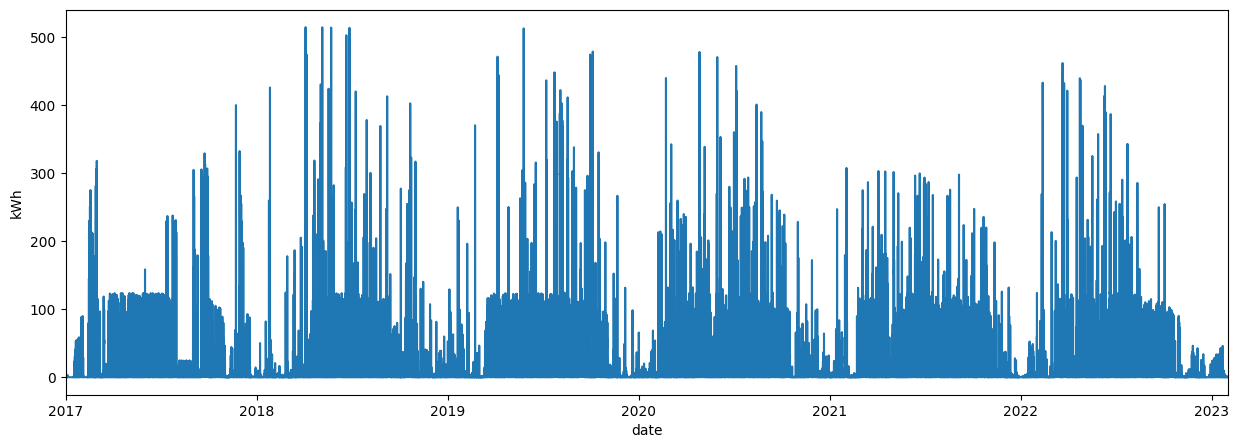

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))
sns.lineplot(x=df.index, y=df["kWh"])
plt.xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2023-02-01"))
plt.show()

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np


class TimeAttributeExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        """
        Constructor para nuestro transformador personalizado.
        """
        self.features_ = [
            "hour",
            "dayofweek",
            "month",
            "is_weekend",
            "hour_sin",
            "hour_cos",
            "doy_sin",
            "doy_cos",
            "month_sin",
            "month_cos",
            "hour_day_interaction",
            "is_night",
        ]

    def fit(self, X, y=None):
        # En transformadores simples, fit no hace nada, pero debe existir.
        return self

    def transform(self, X):
        """
        Aquí movemos tu lógica de create_attributes.
        X debe tener un DatetimeIndex.
        """

        X_copy = X.copy()
        idx = X_copy.index

        # 1. Atributos básicos
        X_copy["hour"] = idx.hour
        X_copy["dayofweek"] = idx.dayofweek
        X_copy["month"] = idx.month
        X_copy["is_weekend"] = (idx.dayofweek >= 5).astype(int)

        # 2. Transformaciones Cíclicas (Crucial para modelos de árboles)
        minutes_since_midnight = idx.hour * 60 + idx.minute

        # Hora Cíclica de alta precisión
        X_copy["hour_sin"] = np.sin(2 * np.pi * minutes_since_midnight / 1440)
        X_copy["hour_cos"] = np.cos(2 * np.pi * minutes_since_midnight / 1440)
        X_copy["doy_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365)
        X_copy["doy_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365)
        # Mes (ciclo de 12)
        X_copy["month_sin"] = np.sin(2 * np.pi * idx.month / 12)
        X_copy["month_cos"] = np.cos(2 * np.pi * idx.month / 12)

        X_copy["hour_day_interaction"] = X_copy["hour"] + (X_copy["dayofweek"] * 24)
        X_copy["is_night"] = ((idx.hour >= 21) | (idx.hour <= 5)).astype(int)
        return X_copy

In [87]:
extractor = TimeAttributeExtractor()
X = df.drop(columns=["kWh"])
y = df["kWh"].reset_index(drop=True)
# Ejecutamos la transformación
df_resultado = extractor.transform(X)
df_resultado

,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,doy_sin,doy_cos,month_sin,month_cos,hour_day_interaction,is_night
date,,,,,,,,,,,,
2017-01-01 11:30:00,11,6,1,1,1.305262e-01,-9.914449e-01,0.017213,0.999852,0.5,8.660254e-01,155,0
2017-01-01 12:00:00,12,6,1,1,1.224647e-16,-1.000000e+00,0.017213,0.999852,0.5,8.660254e-01,156,0
2017-01-01 12:30:00,12,6,1,1,-1.305262e-01,-9.914449e-01,0.017213,0.999852,0.5,8.660254e-01,156,0
2017-01-02 10:00:00,10,0,1,0,5.000000e-01,-8.660254e-01,0.034422,0.999407,0.5,8.660254e-01,10,0
2017-01-02 11:00:00,11,0,1,0,2.588190e-01,-9.659258e-01,0.034422,0.999407,0.5,8.660254e-01,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-16 15:00:00,15,3,3,0,-7.071068e-01,-7.071068e-01,0.961130,0.276097,1.0,6.123234e-17,87,0
2023-03-16 16:00:00,16,3,3,0,-8.660254e-01,-5.000000e-01,0.961130,0.276097,1.0,6.123234e-17,88,0
2023-03-16 17:00:00,17,3,3,0,-9.659258e-01,-2.588190e-01,0.961130,0.276097,1.0,6.123234e-17,89,0


In [88]:
X = df.drop(columns=["kWh"])
y = df[["kWh"]].reset_index(drop=True)
y["kWh"]

0        0.002
1        0.004
2        0.002
3        0.173
4        0.000
         ...  
30566    0.048
30567    0.048
30568    0.000
30569    0.000
30570    0.193
Name: kWh, Length: 30571, dtype: float64

[0]	validation_0-rmse:50.13246	validation_1-rmse:58.55771
[100]	validation_0-rmse:56.70504	validation_1-rmse:63.86634
[200]	validation_0-rmse:60.08058	validation_1-rmse:66.77813
[300]	validation_0-rmse:61.35313	validation_1-rmse:67.89063
[400]	validation_0-rmse:62.85820	validation_1-rmse:69.21530
[500]	validation_0-rmse:63.42664	validation_1-rmse:69.71793
[600]	validation_0-rmse:63.44083	validation_1-rmse:69.73050
[700]	validation_0-rmse:63.58189	validation_1-rmse:69.85542
[800]	validation_0-rmse:63.18902	validation_1-rmse:69.50767
[900]	validation_0-rmse:63.09017	validation_1-rmse:69.42026
[1000]	validation_0-rmse:63.22121	validation_1-rmse:69.53614
[1100]	validation_0-rmse:63.24293	validation_1-rmse:69.55535
[1200]	validation_0-rmse:63.26993	validation_1-rmse:69.57924
[1300]	validation_0-rmse:63.31487	validation_1-rmse:69.61901
[1400]	validation_0-rmse:63.34784	validation_1-rmse:69.64818
[1499]	validation_0-rmse:63.08658	validation_1-rmse:69.41710
Fold 0: RMSE = 58.87
[0]	validation_

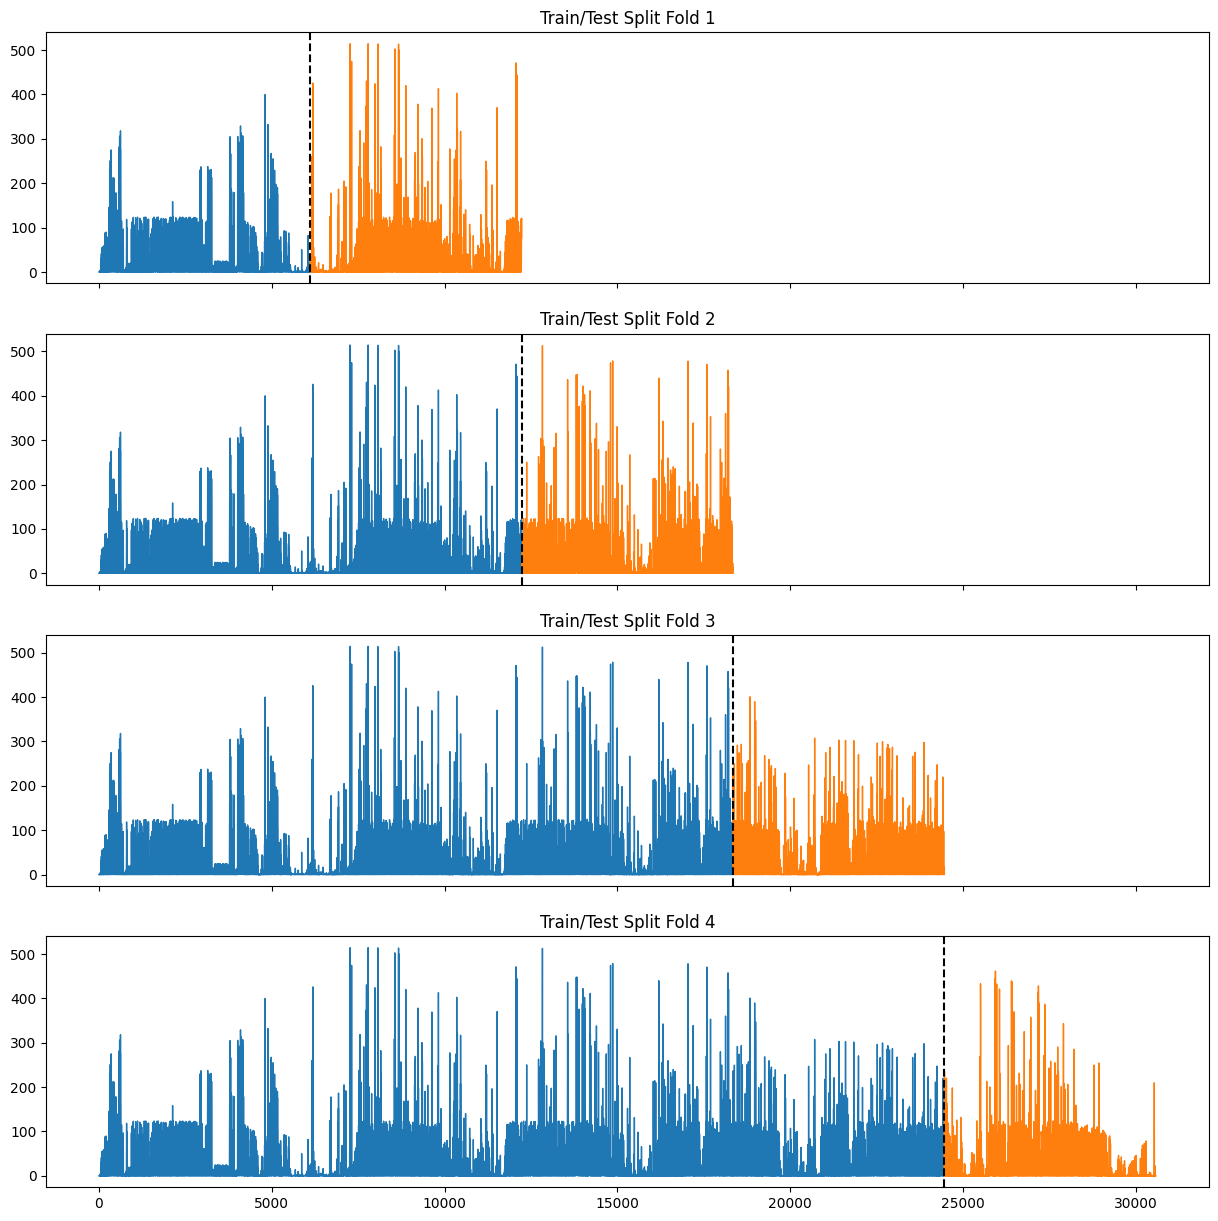

In [101]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import numpy as np

# dividir en 4 folds
ts_cv = TimeSeriesSplit(n_splits=4)

fold = 0
preds = []
scores = []
fig, axs = plt.subplots(4, 1, figsize=(15, 15), sharex=True)

X = df.drop(columns=["kWh"])
y = df[["kWh"]].reset_index(drop=True)

for train_idx, val_idx in ts_cv.split(X):
    X_train, X_test, y_train, y_test = (
        X.iloc[train_idx],
        X.iloc[val_idx],
        y["kWh"].iloc[train_idx],
        y["kWh"].iloc[val_idx],
    )

    xgb_reg = xgb.XGBRegressor(
        booster="gbtree",
        seed=666,
        n_estimators=1500,
        objective="reg:squarederror",
        reg_lambda=0.001,
        max_depth=8,
        eta=0.05,
    )

    pipeline_xgb = Pipeline(
        [
            ("time_attrs", TimeAttributeExtractor()),
            ("xgb_regressor", xgb_reg),
        ]
    )

    # Usar el pipeline completo en lugar de solo xgb_reg
    pipeline_xgb.fit(
        X_train,
        y_train,
        xgb_regressor__eval_set=[(X_train, y_train), (X_test, y_test)],
        xgb_regressor__verbose=100,
    )

    # predicciones y evaluacion usando el pipeline
    y_pred = pipeline_xgb.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)
    print(f"Fold {fold}: RMSE = {score:.2f}")
    train = y.iloc[train_idx]
    test = y.iloc[val_idx]
    train["kWh"].plot(
        ax=axs[fold],
        lw=1,
        label="Training Set",
        title=f"Train/Test Split Fold {fold+1}",
    )
    test["kWh"].plot(ax=axs[fold], lw=1, label="Test Set")
    axs[fold].axvline(test.index.min(), color="black", ls="--")
    fold += 1

print("\nFold scores:", scores)
print("Avg. Score:", np.mean(scores))
plt.show()

In [160]:
import optuna
import warnings

warnings.filterwarnings("ignore")


def objective(trial):
    # Parámetros optimizados
    params = {
        "booster": "gbtree",  # Fijo
        "seed": 666,
        "n_estimators": 800,
        "objective": "reg:squarederror",
        "eta": trial.suggest_loguniform("eta", 0.05, 0.15),
        "max_depth": trial.suggest_int("max_depth", 4, 9),
        # Parámetros adicionales importantes
        "subsample": trial.suggest_uniform("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 5),
    }

    # Optuna decide qué regularización usar
    reg_type = trial.suggest_categorical("regularization", ["L1", "L2", "Gamma"])

    if reg_type == "L1":
        params["reg_alpha"] = trial.suggest_loguniform("reg_alpha", 1e-4, 2.0)
    elif reg_type == "L2":
        params["reg_lambda"] = trial.suggest_loguniform("reg_lambda", 1e-4, 2.0)
    else:  # Gamma
        params["gamma"] = trial.suggest_loguniform("gamma", 1e-4, 2.0)

    # Crear y entrenar modelo directamente con todos los datos
    xgb_reg = xgb.XGBRegressor(**params)

    pipeline = Pipeline(
        [
            ("time_attrs", TimeAttributeExtractor()),
            ("xgb_regressor", xgb_reg),
        ]
    )

    # Entrenar con todos los datos
    pipeline.fit(X, y["kWh"], xgb_regressor__verbose=0)

    # Evaluar en los mismos datos (rápido)
    y_pred = pipeline.predict(X)
    rmse = np.sqrt(mean_squared_error(y["kWh"], y_pred))

    return rmse


# Optimización rápida
print("Optimización: Optuna decide mejor regularización (L1, L2 o Gamma)...")
study = optuna.create_study(direction="minimize", study_name="xgb_best_reg")

# 25 trials para probar bien las 3
study.optimize(objective, n_trials=25, show_progress_bar=True)

# Resultados
print("\n" + "=" * 60)
print("✓ MEJORES PARÁMETROS:")
print("=" * 60)
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.6f}")
    else:
        print(f"{key:20s}: {value}")
print(f"\nMejor RMSE: {study.best_value:.4f}")
print("=" * 60)

# Entrenar modelo final con mejores parámetros
print("\nEntrenando modelo final...")
best_xgb_reg = xgb.XGBRegressor(
    **study.best_params, booster="gbtree", seed=666, objective="reg:squarederror"
)

pipeline_xgb = Pipeline(
    [
        ("time_attrs", TimeAttributeExtractor()),
        ("xgb_regressor", best_xgb_reg),
    ]
)

pipeline_xgb.fit(X, y["kWh"], xgb_regressor__verbose=50)
print("✓ ¡Listo!")

[I 2026-01-27 18:37:32,372] A new study created in memory with name: xgb_best_reg


Optimización: Optuna decide mejor regularización (L1, L2 o Gamma)...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-01-27 18:37:33,195] Trial 0 finished with value: 38.52632841521583 and parameters: {'eta': 0.052744969053441296, 'max_depth': 4, 'subsample': 0.883573527989508, 'colsample_bytree': 0.7296365655810105, 'min_child_weight': 2, 'regularization': 'L1', 'reg_alpha': 0.0003797618464149478}. Best is trial 0 with value: 38.52632841521583.
[I 2026-01-27 18:37:34,643] Trial 1 finished with value: 16.61836841775845 and parameters: {'eta': 0.13051211005132154, 'max_depth': 7, 'subsample': 0.7030744749791019, 'colsample_bytree': 0.9935905555148774, 'min_child_weight': 2, 'regularization': 'Gamma', 'gamma': 0.05769017442095591}. Best is trial 1 with value: 16.61836841775845.
[I 2026-01-27 18:37:36,272] Trial 2 finished with value: 11.307056887607223 and parameters: {'eta': 0.10505334990403184, 'max_depth': 8, 'subsample': 0.9711262852245628, 'colsample_bytree': 0.9875114458405334, 'min_child_weight': 2, 'regularization': 'Gamma', 'gamma': 0.7245240132272195}. Best is trial 2 with value: 11.30

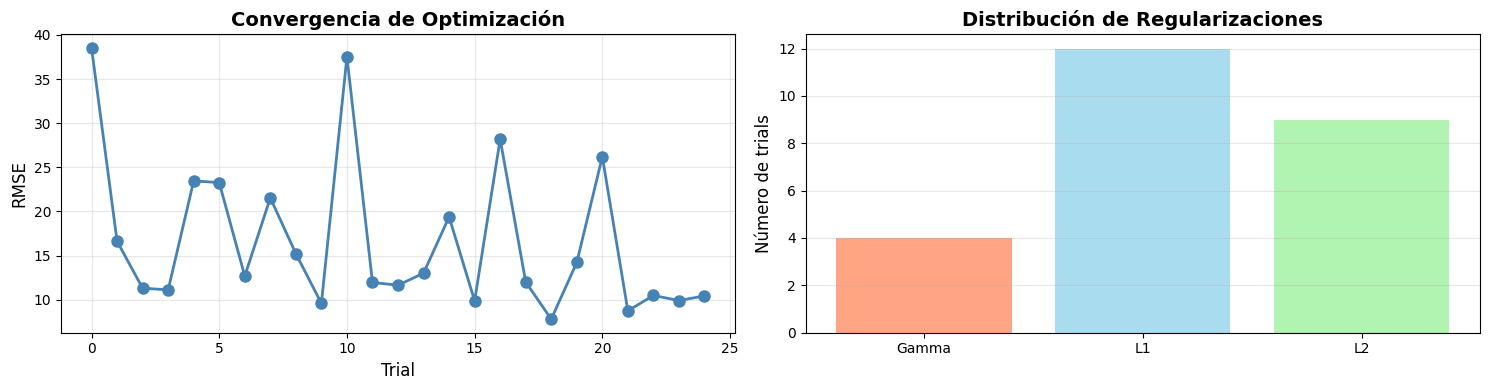


ANÁLISIS POR TIPO DE REGULARIZACIÓN:

L1:
  Trials probados: 12
  Mejor RMSE: 7.8033
  RMSE promedio: 15.6834

L2:
  Trials probados: 9
  Mejor RMSE: 9.5908
  RMSE promedio: 19.0824

Gamma:
  Trials probados: 4
  Mejor RMSE: 11.3071
  RMSE promedio: 13.7075

REGULARIZACIÓN GANADORA:
Tipo: L1
reg_alpha: 0.296501


In [161]:
# Resumen de optimización
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 1. Convergencia
axes[0].plot(
    trials_df.number,
    trials_df.value,
    "o-",
    linewidth=2,
    markersize=8,
    color="steelblue",
)
axes[0].set_xlabel("Trial", fontsize=12)
axes[0].set_ylabel("RMSE", fontsize=12)
axes[0].set_title("Convergencia de Optimización", fontsize=14, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# 2. Distribución de regularizaciones probadas
if "params_regularization" in trials_df.columns:
    reg_counts = trials_df.groupby("params_regularization")["value"].agg(
        ["count", "mean", "min"]
    )
    colors = ["coral", "skyblue", "lightgreen"]
    axes[1].bar(
        reg_counts.index, reg_counts["count"], color=colors, alpha=0.7, label="Intentos"
    )
    axes[1].set_ylabel("Número de trials", fontsize=12)
    axes[1].set_title(
        "Distribución de Regularizaciones", fontsize=14, fontweight="bold"
    )
    axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Análisis detallado por regularización
print("\n" + "=" * 60)
print("ANÁLISIS POR TIPO DE REGULARIZACIÓN:")
print("=" * 60)
if "params_regularization" in trials_df.columns:
    for reg_type in ["L1", "L2", "Gamma"]:
        reg_trials = trials_df[trials_df["params_regularization"] == reg_type]
        if not reg_trials.empty:
            print(f"\n{reg_type}:")
            print(f"  Trials probados: {len(reg_trials)}")
            print(f"  Mejor RMSE: {reg_trials['value'].min():.4f}")
            print(f"  RMSE promedio: {reg_trials['value'].mean():.4f}")

print("\n" + "=" * 60)
print("REGULARIZACIÓN GANADORA:")
print("=" * 60)
winner = study.best_params.get("regularization", "N/A")
print(f"Tipo: {winner}")
if winner == "L1":
    print(f"reg_alpha: {study.best_params.get('reg_alpha', 'N/A'):.6f}")
elif winner == "L2":
    print(f"reg_lambda: {study.best_params.get('reg_lambda', 'N/A'):.6f}")
else:
    print(f"gamma: {study.best_params.get('gamma', 'N/A'):.6f}")
print("=" * 60)

In [183]:
pipeline_xgb.fit(
    X,
    y,
    xgb_regressor__verbose=100,
)
predict = pd.date_range("2023-03-17", "2024-12-17", freq="30min")
predict = pd.DataFrame(index=predict)

predict["kWh"] = pipeline_xgb.predict(predict).clip(min=0)

# Concatenar dataframes
predict = pd.concat([df.loc[df.index >= "2018-01-01"], predict])
predict.tail()

,kWh
2024-12-16 22:00:00,0.043010
2024-12-16 22:30:00,0.000000
2024-12-16 23:00:00,0.000000
2024-12-16 23:30:00,0.000000
2024-12-17 00:00:00,0.236047


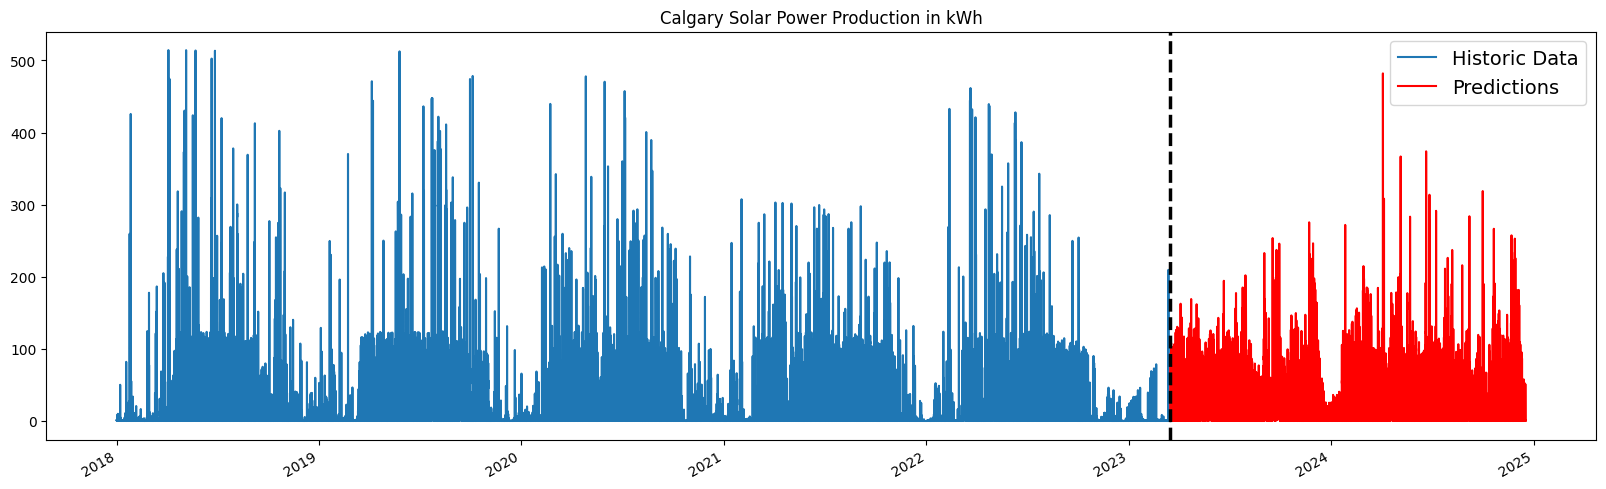

In [184]:
ax = (
    predict["kWh"]
    .loc[predict.index <= "2023-03-17"]
    .plot(figsize=(20, 6), lw=1.5, title="Calgary Solar Power Production in kWh")
)

predict["kWh"].loc[predict.index > "2023-03-17"].plot(style="-", lw=1.5, c="red")

ax.axvline("2023-03-17", color="black", ls="--", lw=2.5)
plt.legend(["Historic Data", "Predictions"], fontsize=14)
plt.show()

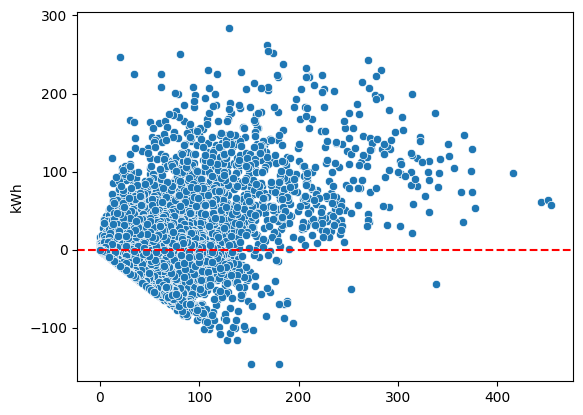

In [185]:
# Analisis de residuos
predicted_full = pipeline_xgb.predict(X).clip(min=0)
residuals = y["kWh"] - predicted_full
sns.scatterplot(x=predicted_full, y=residuals)
plt.axhline(0, color="red", ls="--")
plt.show()

In [186]:
mae = np.mean(np.abs(residuals))
print(f"Mean Absolute Error (MAE): {mae:.2f} kWh")

Mean Absolute Error (MAE): 15.33 kWh


RMSE 2018: 799.84


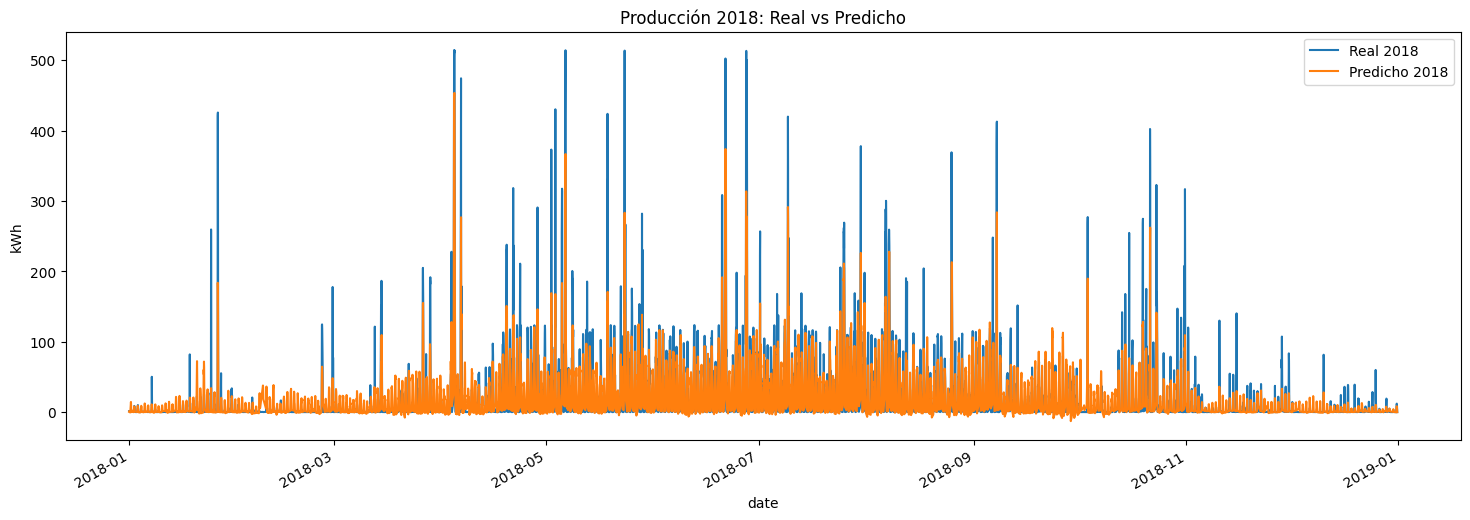

In [187]:
# Predicción y comparación para todo 2018
# Usa el modelo entrenado (xgb_regf) sobre los datos de 2018 ya presentes en X_full
from sklearn.metrics import mean_squared_error

# Extraer datos reales de 2018
pw_2018 = X.loc["2018"].copy()


# Predicciones sobre 2018
pw_2018["prediction"] = pipeline_xgb.predict(pw_2018)
pw_2018["kWh"] = df.loc["2018", "kWh"]
# Métrica rápida
rmse_2018 = mean_squared_error(pw_2018["kWh"], pw_2018["prediction"])
print(f"RMSE 2018: {rmse_2018:0.2f}")

# Gráfico real vs predicho
ax = pw_2018["kWh"].plot(figsize=(18, 6), lw=1.5, label="Real 2018")
pw_2018["prediction"].plot(ax=ax, lw=1.5, label="Predicho 2018")
ax.set_title("Producción 2018: Real vs Predicho")
ax.set_ylabel("kWh")
plt.legend()
plt.show()

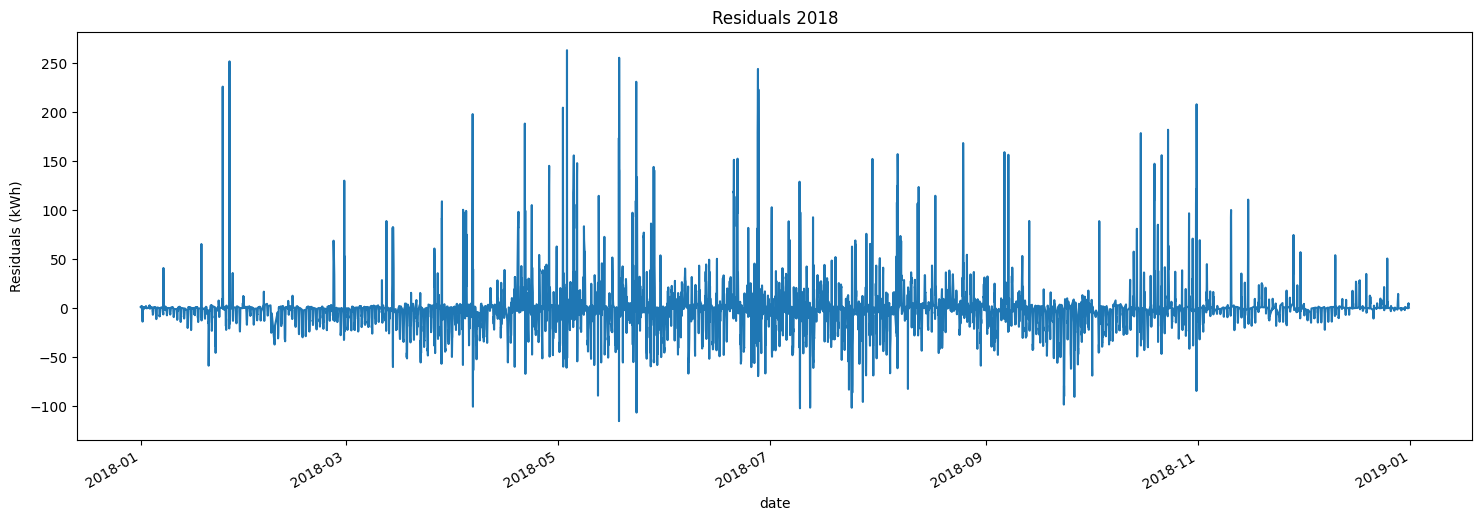

In [188]:
# Residuales 2018

pw_2018["residuals"] = pw_2018["kWh"] - pw_2018["prediction"]
ax = pw_2018["residuals"].plot(figsize=(18, 6), lw=1.5, title="Residuals 2018")
ax.set_ylabel("Residuals (kWh)")
plt.show()

In [ ]:
xgb_best_666 = xgb.XGBRegressor(
    **study.best_params, booster="gbtree", seed=666, objective="reg:squarederror"
)
pipeline_xgb = Pipeline(
    [
        ("time_attrs", TimeAttributeExtractor()),
        ("xgb_regressor", xgb_best_666),
    ]
)

pipeline_xgb.fit(X, y["kWh"], xgb_regressor__verbose=50)
print("✓ ¡Listo!")

✓ ¡Listo!


In [ ]:
len(pipeline_xgb.named_steps["time_attrs"].features_)

12

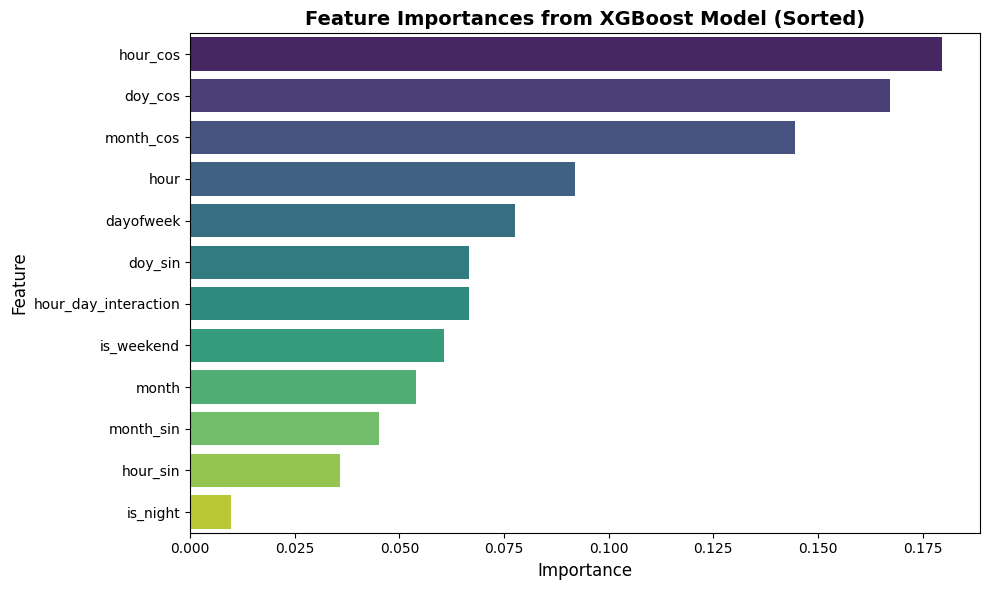


Feature Importances (ordenadas):
             Feature  Importance
            hour_cos    0.179742
             doy_cos    0.167257
           month_cos    0.144554
                hour    0.092003
           dayofweek    0.077646
             doy_sin    0.066689
hour_day_interaction    0.066547
          is_weekend    0.060786
               month    0.053904
           month_sin    0.045205
            hour_sin    0.035864
            is_night    0.009803


In [196]:
importances = pipeline_xgb.named_steps["xgb_regressor"].feature_importances_
features = pipeline_xgb.named_steps["time_attrs"].features_

# Crear DataFrame y ordenar por importancia descendente
import_df = pd.DataFrame({"Feature": features, "Importance": importances})
import_df = import_df.sort_values("Importance", ascending=False)

# Gráfico ordenado
plt.figure(figsize=(10, 6))
sns.barplot(data=import_df, y="Feature", x="Importance", palette="viridis")
plt.title(
    "Feature Importances from XGBoost Model (Sorted)", fontsize=14, fontweight="bold"
)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

# Mostrar tabla ordenada
print("\nFeature Importances (ordenadas):")
print(import_df.sort_values("Importance", ascending=False).to_string(index=False))

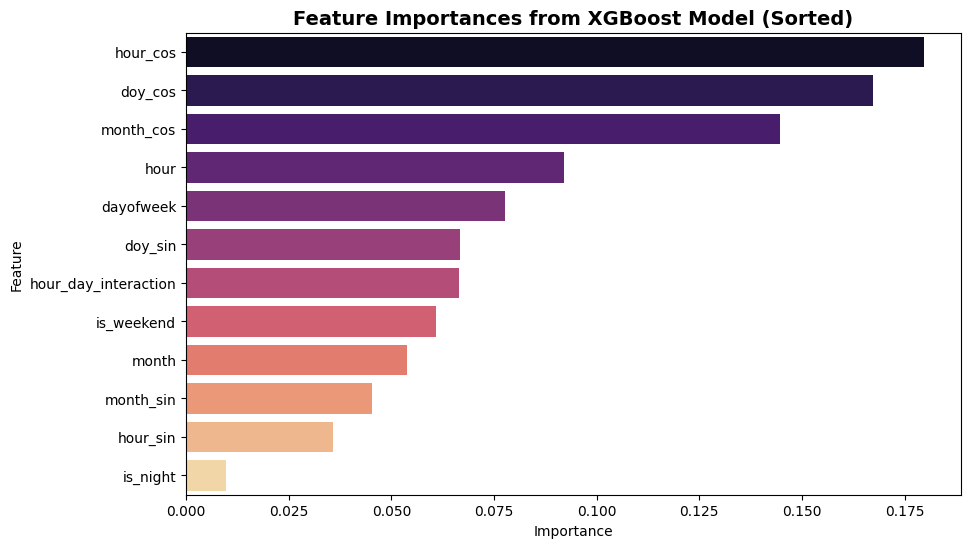

In [ ]:
# 1. Transformamos una muestra pequeña para obtener los nombres reales y su orden
X_sample = X.head(1)
X_transformed_sample = pipeline_xgb.named_steps["time_attrs"].transform(X_sample)
column_names = X_transformed_sample.columns.tolist()

# 2. Obtenemos las importancias del modelo
importances = pipeline_xgb.named_steps["xgb_regressor"].feature_importances_

# 3. Creamos el DataFrame de importancia
# Aquí no hay error posible porque ambos vienen de la ejecución real
import_df = pd.DataFrame(
    {"Feature": column_names, "Importance": importances}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=import_df, y="Feature", x="Importance", palette="magma")
plt.title(
    "Feature Importances from XGBoost Model (Sorted)", fontsize=14, fontweight="bold"
)
plt.show()

#################################################################################################################


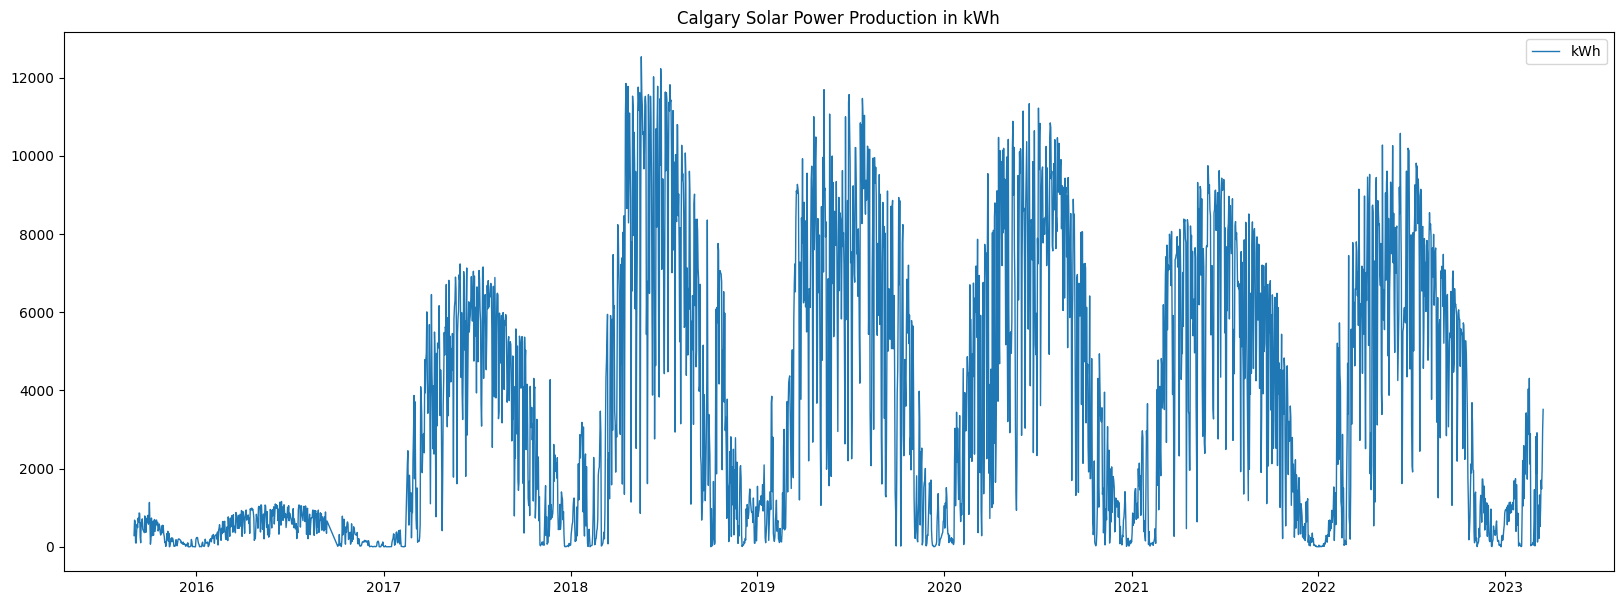

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Preparación robusta del índice temporal y limpieza de columnas
_drop_cols = ["name", "id", "address", "public_url", "installationDate", "uid"]

if "date" in df.columns:
    df["date"] = pd.to_datetime(
        df["date"], format="%Y/%m/%d %I:%M:%S %p", errors="coerce"
    )
    df = df.drop(columns=[c for c in _drop_cols if c in df.columns])
    df = df.set_index("date", drop=True)  # Datetime
else:
    df = df.drop(columns=[c for c in _drop_cols if c in df.columns], errors="ignore")
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

# crear acumulado diario y mantener un DataFrame
df = df.groupby(df.index.date)["kWh"].sum().to_frame()
df.plot(style="-", figsize=(20, 7), lw=1, title="Calgary Solar Power Production in kWh")
plt.show()

(2716, 1)
(1841, 1)


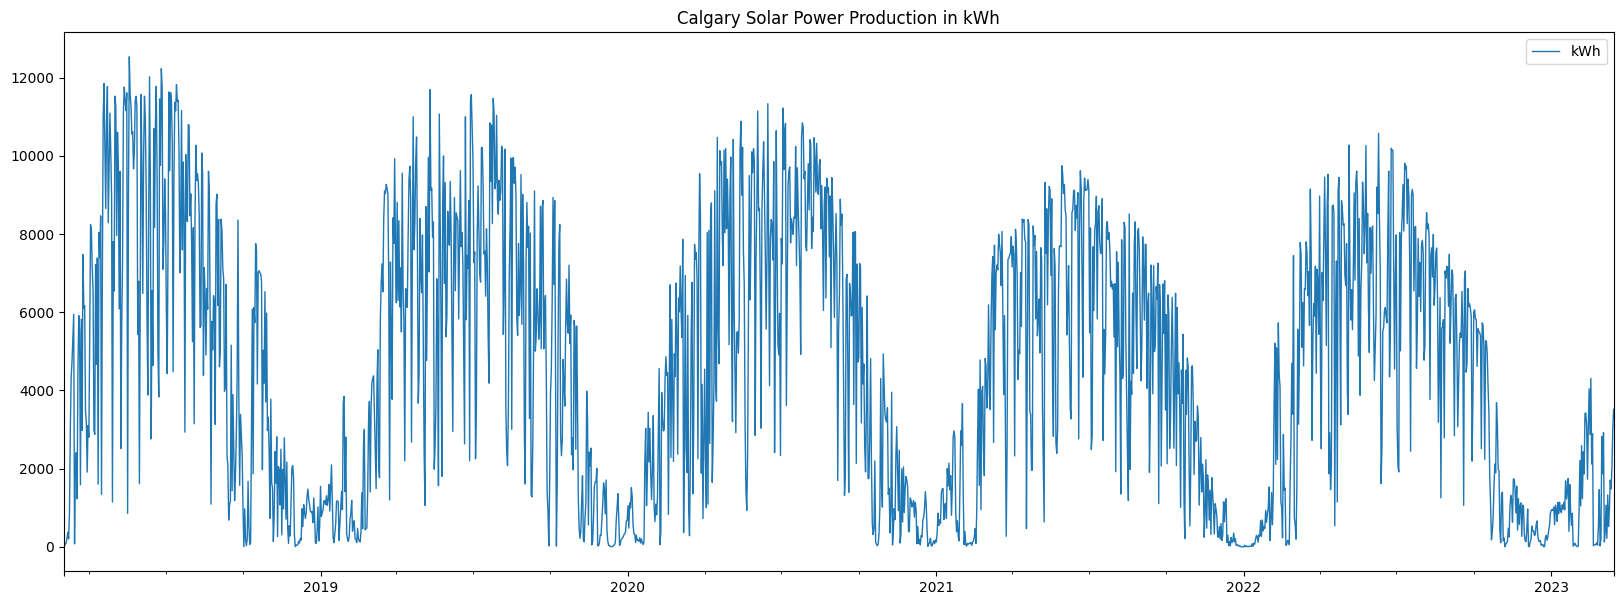

In [3]:
# filter data after 2018-03-01 once index is a DatetimeIndex
print(df.shape)
df.index = pd.to_datetime(df.index)
df = df[df.index > pd.Timestamp("2018-03-01")]
print(df.shape)
df.plot(style="-", figsize=(20, 7), lw=1, title="Calgary Solar Power Production in kWh")
plt.show()

In [4]:
df.index

DatetimeIndex(['2018-03-02', '2018-03-03', '2018-03-04', '2018-03-05',
               '2018-03-06', '2018-03-07', '2018-03-08', '2018-03-09',
               '2018-03-10', '2018-03-11',
               ...
               '2023-03-07', '2023-03-08', '2023-03-09', '2023-03-10',
               '2023-03-11', '2023-03-12', '2023-03-13', '2023-03-14',
               '2023-03-15', '2023-03-16'],
              dtype='datetime64[s]', length=1841, freq=None)

In [ ]:
# Agregamos caracteristicas
def create_attributes(df_done):
    df_done = df_done.copy()
    df_done["day"] = df_done.index.day
    df_done["dayofweek"] = df_done.index.dayofweek
    df_done["month"] = df_done.index.month
    df_done["quarter"] = df_done.index.quarter
    df_done["year"] = df_done.index.year
    df_done["dayofyear"] = df_done.index.dayofyear

    df_done["kWh_lag1"] = df_done["kWh"].shift(1)
    df_done["kWh_lag7"] = df_done["kWh"].shift(7)
    for window in [7, 14, 30]:
        df_done[f"kWh_roll{window}_mean"] = (
            df_done["kWh_lag1"].rolling(window=window, min_periods=1).mean()
        )
        df_done[f"kWh_roll{window}_std"] = (
            df_done["kWh_lag1"].rolling(window=window, min_periods=1).std().fillna(0)
        )
    return df_done


df = create_attributes(df)
df.head()

,kWh,day,dayofweek,month,quarter,year,dayofyear,kWh_lag1,kWh_lag7,kWh_roll7_mean,kWh_roll7_std,kWh_roll14_mean,kWh_roll14_std,kWh_roll30_mean,kWh_roll30_std
2018-03-02,19.479,2,4,3,1,2018,61,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000
2018-03-03,32.488,3,5,3,1,2018,62,19.479,NaN,19.479000,0.000000,19.479000,0.000000,19.479000,0.000000
2018-03-04,66.267,4,6,3,1,2018,63,32.488,NaN,25.983500,9.198752,25.983500,9.198752,25.983500,9.198752
2018-03-05,96.467,5,0,3,1,2018,64,66.267,NaN,39.411333,24.150127,39.411333,24.150127,39.411333,24.150127
2018-03-06,212.790,6,1,3,1,2018,65,96.467,NaN,53.675250,34.679336,53.675250,34.679336,53.675250,34.679336


In [5]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np


class TimeAttributeExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        """
        Constructor para nuestro transformador personalizado.
        """
        self.features_ = ["day", "dayofweek", "month", "quarter", "year", "dayofyear"]

    def fit(self, X, y=None):
        # En transformadores simples, fit no hace nada, pero debe existir.
        return self

    def transform(self, X):
        """
        Aquí movemos tu lógica de create_attributes.
        X debe tener un DatetimeIndex.
        """
        X_copy = X.copy()

        # Atributos de calendario
        X_copy["day"] = X_copy.index.day
        X_copy["dayofweek"] = X_copy.index.dayofweek
        X_copy["month"] = X_copy.index.month
        X_copy["quarter"] = X_copy.index.quarter
        X_copy["year"] = X_copy.index.year
        X_copy["dayofyear"] = X_copy.index.dayofyear
        return X_copy

In [24]:
X = df.drop(["kWh"], axis=1)
y = df["kWh"]
print(y.head())
for train_idx, val_idx in ts_cv.split(X):
    X_train, X_test, y_train, y_test = (
        X.iloc[train_idx],
        X.iloc[val_idx],
        y.iloc[train_idx],
        y.iloc[val_idx],
    )
    print(y_train.head())

2018-03-02     19.479
2018-03-03     32.488
2018-03-04     66.267
2018-03-05     96.467
2018-03-06    212.790
Name: kWh, dtype: float64
2018-03-02     19.479
2018-03-03     32.488
2018-03-04     66.267
2018-03-05     96.467
2018-03-06    212.790
Name: kWh, dtype: float64
2018-03-02     19.479
2018-03-03     32.488
2018-03-04     66.267
2018-03-05     96.467
2018-03-06    212.790
Name: kWh, dtype: float64
2018-03-02     19.479
2018-03-03     32.488
2018-03-04     66.267
2018-03-05     96.467
2018-03-06    212.790
Name: kWh, dtype: float64
2018-03-02     19.479
2018-03-03     32.488
2018-03-04     66.267
2018-03-05     96.467
2018-03-06    212.790
Name: kWh, dtype: float64


[0]	validation_0-rmse:3880.26548	validation_1-rmse:3401.76219
[100]	validation_0-rmse:4616.30315	validation_1-rmse:4358.87339
[200]	validation_0-rmse:5265.16746	validation_1-rmse:5090.75973
[300]	validation_0-rmse:5468.77040	validation_1-rmse:5314.30383
[400]	validation_0-rmse:5601.53415	validation_1-rmse:5458.96592
[500]	validation_0-rmse:5658.57986	validation_1-rmse:5520.88550
[600]	validation_0-rmse:5755.54847	validation_1-rmse:5625.83524
[700]	validation_0-rmse:5856.99948	validation_1-rmse:5735.25371
[800]	validation_0-rmse:5964.60259	validation_1-rmse:5850.91200
[900]	validation_0-rmse:5977.21055	validation_1-rmse:5864.43852
[999]	validation_0-rmse:5990.30680	validation_1-rmse:5878.48362
Fold 0: RMSE = 2995.03
[0]	validation_0-rmse:3646.06066	validation_1-rmse:3542.34510
[100]	validation_0-rmse:4626.23103	validation_1-rmse:4475.09726
[200]	validation_0-rmse:5348.52711	validation_1-rmse:5195.37106
[300]	validation_0-rmse:5621.74773	validation_1-rmse:5468.73032
[400]	validation_0-rm

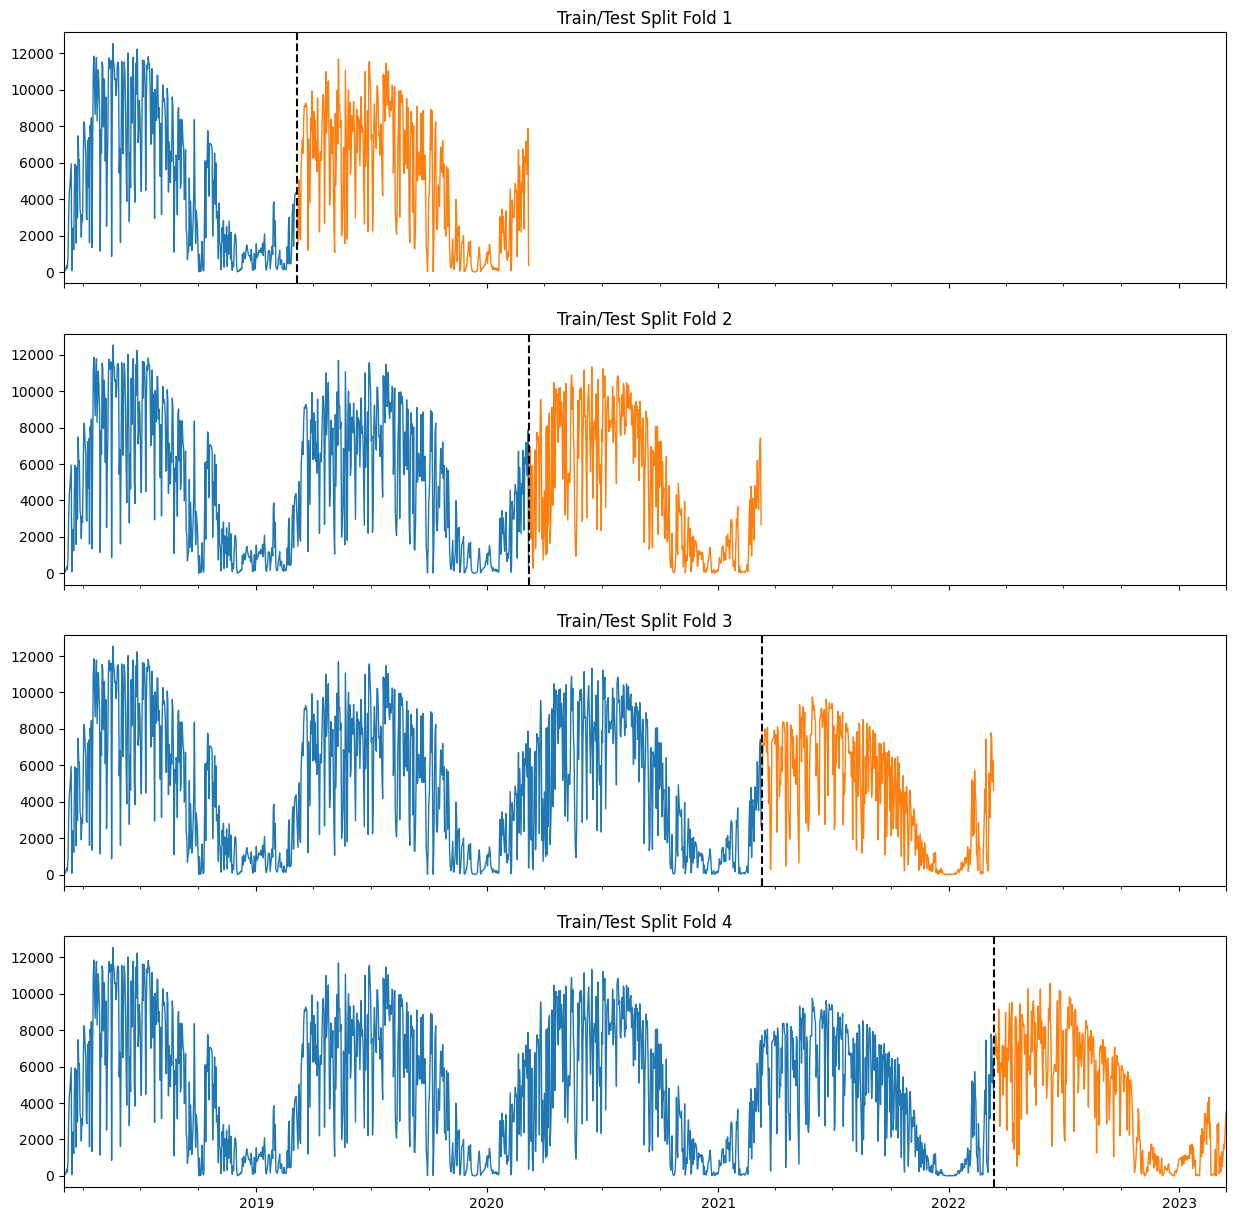

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import numpy as np


X = df.drop(["kWh"], axis=1)
y = df["kWh"].to_frame()

# dividir en 4 folds
ts_cv = TimeSeriesSplit(n_splits=4)

fold = 0
preds = []
scores = []
fig, axs = plt.subplots(4, 1, figsize=(15, 15), sharex=True)


for train_idx, val_idx in ts_cv.split(X):
    X_train, X_test, y_train, y_test = (
        X.iloc[train_idx],
        X.iloc[val_idx],
        y.iloc[train_idx],
        y.iloc[val_idx],
    )

    xgb_reg = xgb.XGBRegressor(
        booster="gbtree",
        seed=666,
        n_estimators=1000,
        objective="reg:squarederror",
        reg_lambda=0.001,
        max_depth=5,
        eta=0.01,
    )

    pipeline_xgb = Pipeline(
        [
            ("time_attrs", TimeAttributeExtractor()),
            ("xgb_regressor", xgb_reg),
        ]
    )

    # Usar el pipeline completo en lugar de solo xgb_reg
    pipeline_xgb.fit(
        X_train,
        y_train,
        xgb_regressor__eval_set=[(X_train, y_train), (X_test, y_test)],
        xgb_regressor__verbose=100,
    )

    # predicciones y evaluacion usando el pipeline
    y_pred = pipeline_xgb.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)
    print(f"Fold {fold}: RMSE = {score:.2f}")
    train = y.iloc[train_idx]
    test = y.iloc[val_idx]
    train["kWh"].plot(
        ax=axs[fold],
        lw=1,
        label="Training Set",
        title=f"Train/Test Split Fold {fold+1}",
    )
    test["kWh"].plot(ax=axs[fold], lw=1, label="Test Set")
    axs[fold].axvline(test.index.min(), color="black", ls="--")
    fold += 1

print("\nFold scores:", scores)
print("Avg. Score:", np.mean(scores))
plt.show()

In [50]:
X.index.max()

Timestamp('2023-03-16 00:00:00')

In [ ]:
pipeline_xgb.fit(
    X,
    y,
    xgb_regressor__verbose=100,
)
predict = pd.date_range("2023-03-17", "2023-09-17", freq="D")
predict = pd.DataFrame(index=predict)

predict["kWh"] = pipeline_xgb.predict(predict)

# Concatenar dataframes
predict = pd.concat([df.loc[df.index >= "2018-01-01"], predict])
predict.head()

,kWh
2018-03-02,19.479
2018-03-03,32.488
2018-03-04,66.267
2018-03-05,96.467
2018-03-06,212.790


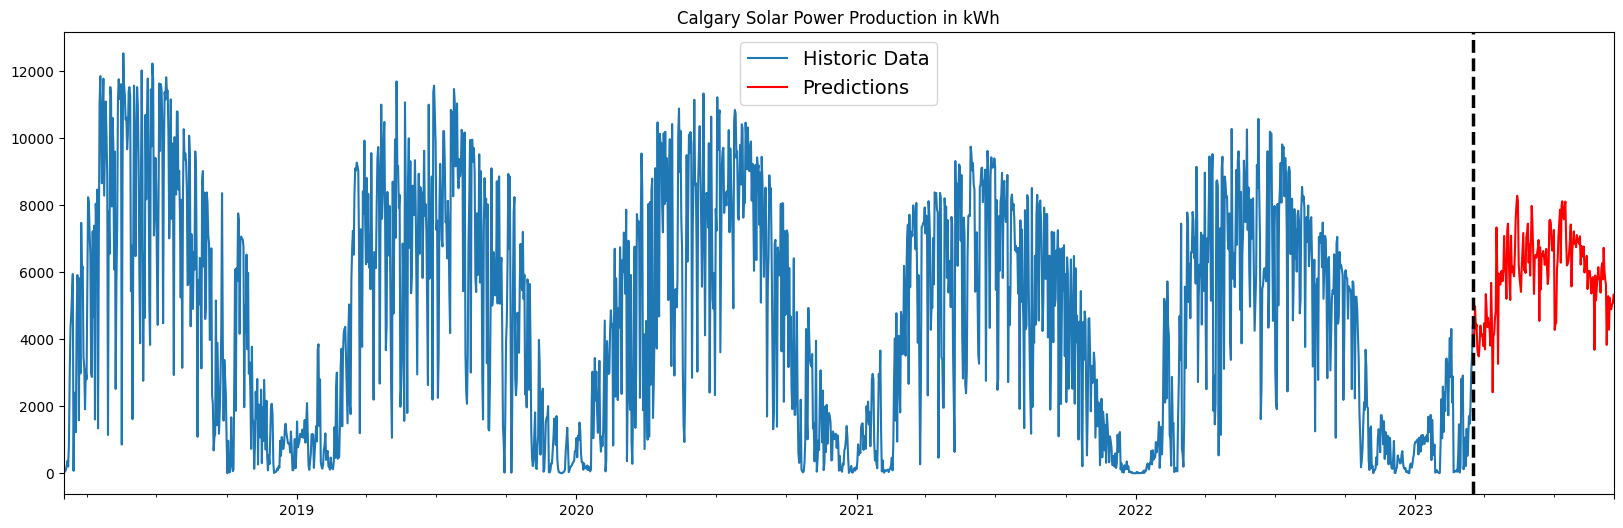

In [57]:
ax = (
    predict["kWh"]
    .loc[predict.index <= "2023-03-17"]
    .plot(figsize=(20, 6), lw=1.5, title="Calgary Solar Power Production in kWh")
)
predict["kWh"].loc[predict.index > "2023-03-17"].plot(style="-", lw=1.5, c="red")
ax.axvline("2023-03-17", color="black", ls="--", lw=2.5)
plt.legend(["Historic Data", "Predictions"], fontsize=14)
plt.show()

RMSE 2018: 2378974.11


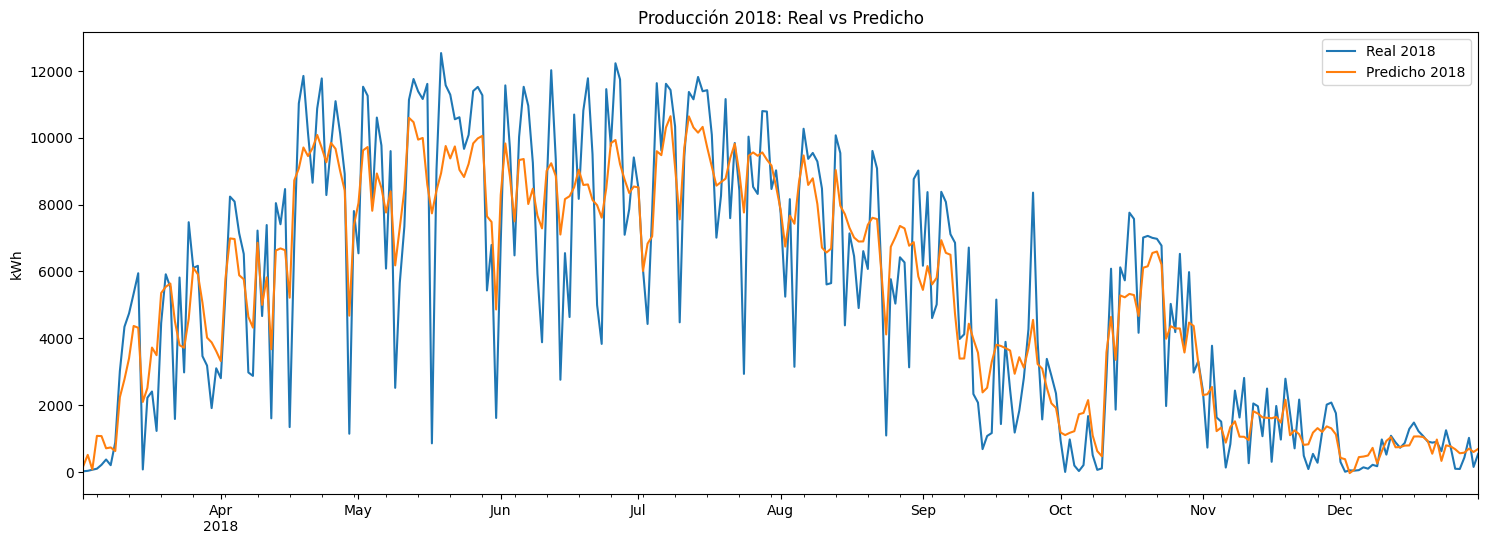

In [61]:
# Predicción y comparación para todo 2018
# Usa el modelo entrenado (xgb_regf) sobre los datos de 2018 ya presentes en X_full
from sklearn.metrics import mean_squared_error

# Extraer datos reales de 2018
pw_2018 = df.loc["2018"].copy()


# Predicciones sobre 2018
pw_2018["prediction"] = pipeline_xgb.predict(pw_2018.drop(["kWh"], axis=1))

# Métrica rápida
rmse_2018 = mean_squared_error(pw_2018["kWh"], pw_2018["prediction"])
print(f"RMSE 2018: {rmse_2018:0.2f}")

# Gráfico real vs predicho
ax = pw_2018["kWh"].plot(figsize=(18, 6), lw=1.5, label="Real 2018")
pw_2018["prediction"].plot(ax=ax, lw=1.5, label="Predicho 2018")
ax.set_title("Producción 2018: Real vs Predicho")
ax.set_ylabel("kWh")
plt.legend()
plt.show()